# XGBoost — A Beginner-Friendly Learning Notebook

This notebook teaches XGBoost through a complete **binary classification** project.

We will:

1. Understand XGBoost in plain language.
2. Create separate **training, validation, and test** sets.
3. Train an `XGBClassifier`.
4. Use the validation set for **early stopping**.
5. Evaluate once on the untouched test set.
6. Understand every parameter used in the model.
7. inspect learning curves and feature importance.
8. Save and reload the trained model.

> **Dataset:** Breast Cancer Wisconsin dataset included with scikit-learn.  
> **Target:** Predict whether a tumor is malignant or benign.  
> This notebook is for education, not medical decision-making.

## 1. What is XGBoost?

**XGBoost** means **Extreme Gradient Boosting**.

The simple idea:

- XGBoost builds many small decision trees.
- Tree 1 makes some mistakes.
- Tree 2 focuses more on correcting Tree 1's mistakes.
- Tree 3 corrects the remaining mistakes.
- This continues until the model becomes strong or training stops.

A useful mental model:

> **One weak tree + another correction tree + another correction tree = one strong model**

XGBoost is commonly used for structured or tabular data such as customer records, transactions, measurements, and business data.

## 2. Why three datasets?

| Dataset | Used for | Simple meaning |
|---|---|---|
| **Training set** | Learning tree rules | The model studies this data. |
| **Validation set** | Early stopping and model choices | A practice exam used while developing the model. |
| **Test set** | One final unbiased evaluation | The final exam. Do not use it to tune the model. |

In this notebook we use approximately:

- **70% training**
- **15% validation**
- **15% test**

The test set stays untouched until the final evaluation.

## 3. Install packages

Run this cell only when the packages are missing. In Google Colab, uncomment the command.

In [1]:
# Uncomment when needed:
# %pip install -q xgboost scikit-learn pandas numpy matplotlib

## 4. Imports and reproducibility

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('XGBoost version:', xgb.__version__)
print('scikit-learn version:', sklearn.__version__)

XGBoost version: 3.1.3
scikit-learn version: 1.8.0


### Why `random_state=42`?

Some steps randomly shuffle rows or sample data. A fixed random seed makes the result repeatable. The number `42` has no special machine-learning meaning; any fixed integer is acceptable.

## 5. Load the dataset

In [3]:
data = load_breast_cancer(as_frame=True)

X = data.data.copy()          # Input columns (features)
y = data.target.copy()        # Output column (target)

# The original dataset uses 0 = malignant and 1 = benign.
class_names = list(data.target_names)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Classes:', dict(enumerate(class_names)))
X.head()

Feature matrix shape: (569, 30)
Target shape: (569,)
Classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Important terms

- **Row / sample:** One patient record.
- **Feature:** One input measurement used by the model.
- **Target / label:** The answer the model tries to predict.
- **Class 0:** Malignant.
- **Class 1:** Benign.

In [4]:
summary = pd.DataFrame({
    'dtype': X.dtypes.astype(str),
    'missing_values': X.isna().sum(),
    'minimum': X.min(),
    'maximum': X.max(),
    'mean': X.mean(),
})

print('Missing values in all features:', int(X.isna().sum().sum()))
print('\nClass counts:')
print(y.value_counts().rename(index={0: 'malignant (0)', 1: 'benign (1)'}))
summary.head(10)

Missing values in all features: 0

Class counts:
target
benign (1)       357
malignant (0)    212
Name: count, dtype: int64


,dtype,missing_values,minimum,maximum,mean
mean radius,float64,0,6.98100,28.11000,14.127292
mean texture,float64,0,9.71000,39.28000,19.289649
mean perimeter,float64,0,43.79000,188.50000,91.969033
mean area,float64,0,143.50000,2501.00000,654.889104
mean smoothness,float64,0,0.05263,0.16340,0.096360
mean compactness,float64,0,0.01938,0.34540,0.104341
mean concavity,float64,0,0.00000,0.42680,0.088799
mean concave points,float64,0,0.00000,0.20120,0.048919
mean symmetry,float64,0,0.10600,0.30400,0.181162
mean fractal dimension,float64,0,0.04996,0.09744,0.062798


## 6. Split into train, validation, and test sets

We split twice:

1. Keep **15%** as the final test set.
2. Split the remaining **85%** so that about **15% of the full dataset** becomes validation data.

`stratify=y` keeps approximately the same class ratio in every split. This matters when classes are not perfectly balanced.

In [5]:
# First split: 85% development data and 15% final test data
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y,
)

# We want validation to be 15% of the full data.
# Validation fraction inside the 85% development set = 0.15 / 0.85
validation_fraction_of_dev = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=validation_fraction_of_dev,
    random_state=RANDOM_STATE,
    stratify=y_dev,
)

split_table = pd.DataFrame({
    'rows': [len(X_train), len(X_val), len(X_test)],
    'percentage': [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
}, index=['train', 'validation', 'test'])

split_table.round(2)

,rows,percentage
train,397,69.77
validation,86,15.11
test,86,15.11


In [6]:
def class_distribution(labels, name):
    proportions = labels.value_counts(normalize=True).sort_index()
    return pd.Series({
        'dataset': name,
        'malignant_%': proportions.get(0, 0) * 100,
        'benign_%': proportions.get(1, 0) * 100,
    })

pd.DataFrame([
    class_distribution(y_train, 'train'),
    class_distribution(y_val, 'validation'),
    class_distribution(y_test, 'test'),
]).set_index('dataset').round(2)

,malignant_%,benign_%
dataset,,
train,37.28,62.72
validation,37.21,62.79
test,37.21,62.79


## 7. Parameters used in our XGBoost model

A **parameter** is a setting we choose before training. It controls how the model learns.

| Parameter | Value used | Very simple explanation | What happens when increased? |
|---|---:|---|---|
| `objective` | `binary:logistic` | Tells XGBoost this is a two-class problem and that we want probabilities. | Not a numeric parameter. Choose it based on the task. |
| `n_estimators` | `1000` | Maximum number of trees XGBoost may build. | More learning capacity and more training time. Early stopping may stop before 1000. |
| `learning_rate` | `0.03` | How strongly each new tree changes the model. | Faster learning, but a greater chance of overshooting or overfitting. |
| `max_depth` | `4` | Maximum number of levels in each tree. | Trees become more complex and may overfit. |
| `min_child_weight` | `2` | Prevents a split when the resulting child is based on too little information. | Fewer, safer splits; model becomes more conservative. |
| `gamma` | `0` | Minimum improvement required before making a new split. | Fewer splits; model becomes simpler. |
| `subsample` | `0.85` | Each tree trains on 85% of the training rows, selected randomly. | Values closer to 1 use more rows; lower values add randomness. |
| `colsample_bytree` | `0.85` | Each tree can use 85% of the features, selected randomly. | Values closer to 1 let every tree inspect more features. |
| `reg_alpha` | `0.0` | L1 regularization: penalizes unnecessary leaf weights. | More regularization; can make the model simpler. |
| `reg_lambda` | `1.0` | L2 regularization: smoothly shrinks leaf weights. | More regularization; model becomes more conservative. |
| `scale_pos_weight` | `1.0` | Gives extra weight to class 1 when classes are imbalanced. | The model pays more attention to class 1. Calculate carefully for your class definition. |
| `tree_method` | `hist` | Uses the fast histogram-based tree-building algorithm. | Not a numeric parameter. `hist` is usually a strong default. |
| `eval_metric` | `logloss` | The score watched during training. Lower log loss is better. | Not a numeric parameter. Choose a metric that matches the goal. |
| `early_stopping_rounds` | `40` | Stop when validation log loss does not improve for 40 trees. | More patience; training may continue longer. |
| `random_state` | `42` | Makes random choices repeatable. | The number itself does not make the model better. |
| `n_jobs` | `2` | Allows up to two CPU worker threads for this small example. | More threads may train faster, but can consume more machine resources. |
| `verbosity` | `0` | Controls XGBoost's printed messages. | Higher values print more diagnostic information. |

### The three most important parameters to learn first

1. `learning_rate`: size of each correction.
2. `n_estimators`: maximum number of corrections/trees.
3. `max_depth`: complexity of each tree.

A common pattern is a **small learning rate + many possible trees + early stopping**.

## 8. Create the model

Every argument used below is explained in the table above.

In [7]:
model = XGBClassifier(
    objective='binary:logistic',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    gamma=0.0,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    scale_pos_weight=1.0,
    tree_method='hist',
    eval_metric='logloss',
    early_stopping_rounds=40,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbosity=0,
)

model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",40
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## 9. Train the model

### Parameters passed to `.fit()`

| Fit parameter | Simple explanation |
|---|---|
| `X_train` | Training input features. |
| `y_train` | Correct training answers. |
| `eval_set=[(X_train, y_train), (X_val, y_val)]` | Datasets whose scores are recorded after every tree. The **last set**, validation, is used for early stopping. |
| `verbose=False` | Do not print one line for every boosting round. |

The model learns only from the training set. The validation set is watched to decide when to stop.

In [8]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print('Training finished.')
print('Best tree index:', model.best_iteration)
print('Best validation log loss:', round(float(model.best_score), 5))
print('Number of trees effectively used:', model.best_iteration + 1)

Training finished.
Best tree index: 708
Best validation log loss: 0.03146
Number of trees effectively used: 709


### How early stopping works

Suppose validation log loss improves until tree 173. If the next 40 trees fail to improve it, training stops. This prevents us from blindly using all 1000 trees.

- Training score often keeps improving because the model sees training data directly.
- Validation score tells us whether learning still helps on unseen development data.
- When validation performance stops improving, additional trees may only memorize training details.

## 10. Plot the learning curve

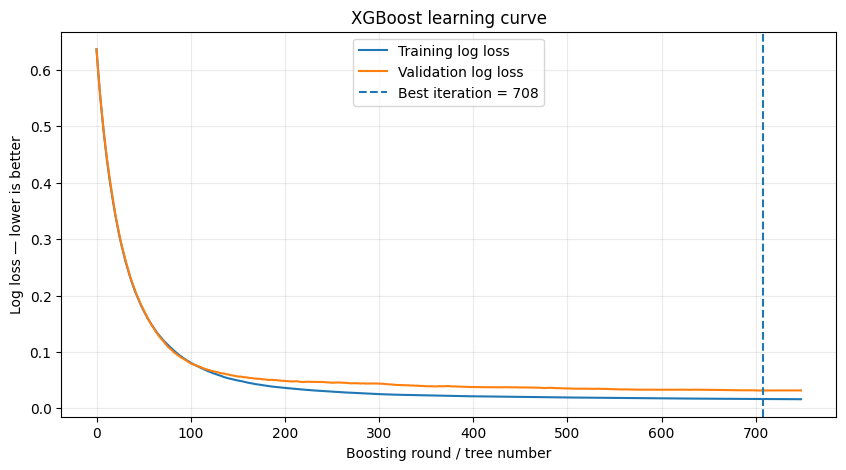

In [9]:
results = model.evals_result()
train_logloss = results['validation_0']['logloss']
val_logloss = results['validation_1']['logloss']

plt.figure(figsize=(10, 5))
plt.plot(train_logloss, label='Training log loss')
plt.plot(val_logloss, label='Validation log loss')
plt.axvline(model.best_iteration, linestyle='--', label=f'Best iteration = {model.best_iteration}')
plt.xlabel('Boosting round / tree number')
plt.ylabel('Log loss — lower is better')
plt.title('XGBoost learning curve')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Reading the graph

- If both lines are high, the model may be **underfitting**.
- If training loss falls but validation loss rises, the model is likely **overfitting**.
- The dashed line shows the best validation round found by early stopping.

## 11. A reusable evaluation function

In [10]:
def evaluate_classifier(model, X_part, y_part, dataset_name):
    predictions = model.predict(X_part)
    probabilities = model.predict_proba(X_part)[:, 1]

    metrics = {
        'dataset': dataset_name,
        'accuracy': accuracy_score(y_part, predictions),
        'precision_class_1': precision_score(y_part, predictions, zero_division=0),
        'recall_class_1': recall_score(y_part, predictions, zero_division=0),
        'f1_class_1': f1_score(y_part, predictions, zero_division=0),
        'roc_auc': roc_auc_score(y_part, probabilities),
        'log_loss': log_loss(y_part, probabilities),
    }
    return metrics, predictions, probabilities

### Metric meanings

| Metric | Very simple meaning |
|---|---|
| `accuracy` | Fraction of all predictions that were correct. |
| `precision` | When the model predicts class 1, how often is it correct? |
| `recall` | Of all real class-1 cases, how many did the model find? |
| `F1` | A balance between precision and recall. |
| `ROC AUC` | How well probabilities rank the two classes. 1.0 is perfect; 0.5 is random ranking. |
| `log loss` | Punishes wrong probabilities, especially confident wrong answers. Lower is better. |

For this dataset, class 1 means **benign**. In many real projects you may redefine the positive class so that recall and precision describe the outcome you care about.

## 12. Evaluate on the validation set

In [11]:
val_metrics, val_predictions, val_probabilities = evaluate_classifier(
    model, X_val, y_val, 'validation'
)

pd.DataFrame([val_metrics]).set_index('dataset').round(4)

,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,log_loss
dataset,,,,,,
validation,0.9884,0.9818,1.0,0.9908,1.0,0.0315


              precision    recall  f1-score   support

   malignant     1.0000    0.9688    0.9841        32
      benign     0.9818    1.0000    0.9908        54

    accuracy                         0.9884        86
   macro avg     0.9909    0.9844    0.9875        86
weighted avg     0.9886    0.9884    0.9883        86



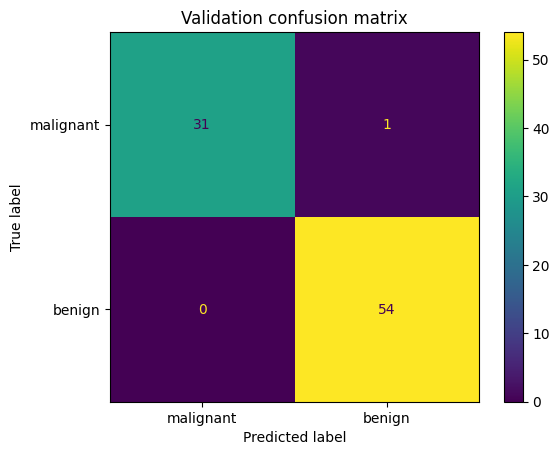

In [12]:
print(classification_report(
    y_val,
    val_predictions,
    target_names=class_names,
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_predictions,
    display_labels=class_names,
    values_format='d',
)
plt.title('Validation confusion matrix')
plt.show()

## 13. Final evaluation on the untouched test set

This is the first time we use the test set. After seeing this score, do not repeatedly change parameters to improve the same test result. Repeated tuning on the test set turns it into another validation set.

In [13]:
test_metrics, test_predictions, test_probabilities = evaluate_classifier(
    model, X_test, y_test, 'test'
)

comparison = pd.DataFrame([val_metrics, test_metrics]).set_index('dataset')
comparison.round(4)

,accuracy,precision_class_1,recall_class_1,f1_class_1,roc_auc,log_loss
dataset,,,,,,
validation,0.9884,0.9818,1.000,0.9908,1.0000,0.0315
test,0.9535,0.9630,0.963,0.9630,0.9936,0.0877


              precision    recall  f1-score   support

   malignant     0.9375    0.9375    0.9375        32
      benign     0.9630    0.9630    0.9630        54

    accuracy                         0.9535        86
   macro avg     0.9502    0.9502    0.9502        86
weighted avg     0.9535    0.9535    0.9535        86



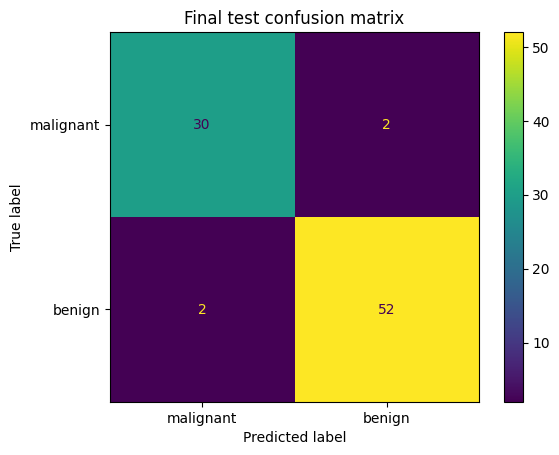

In [14]:
print(classification_report(
    y_test,
    test_predictions,
    target_names=class_names,
    digits=4,
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=class_names,
    values_format='d',
)
plt.title('Final test confusion matrix')
plt.show()

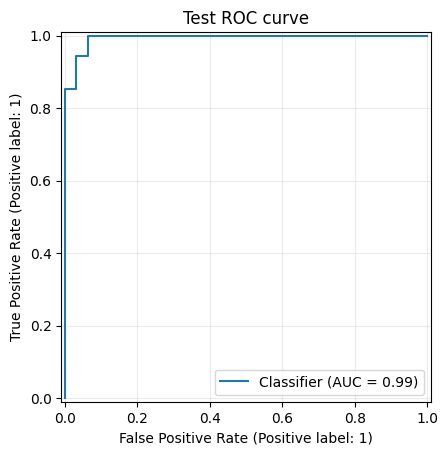

In [15]:
RocCurveDisplay.from_predictions(y_test, test_probabilities)
plt.title('Test ROC curve')
plt.grid(alpha=0.25)
plt.show()

## 14. Inspect predicted probabilities

`predict()` returns a class such as 0 or 1.  
`predict_proba()` returns probabilities.

By default, binary classification usually predicts class 1 when its probability is at least `0.5`.

In [16]:
example_predictions = X_test.head(10).copy()
example_predictions['actual_class'] = y_test.head(10).map({0: 'malignant', 1: 'benign'})
example_predictions['probability_benign'] = model.predict_proba(X_test.head(10))[:, 1]
example_predictions['predicted_class'] = model.predict(X_test.head(10))
example_predictions['predicted_label'] = example_predictions['predicted_class'].map({0: 'malignant', 1: 'benign'})

example_predictions[['actual_class', 'probability_benign', 'predicted_label']].round(4)

,actual_class,probability_benign,predicted_label
194,malignant,0.0092,malignant
328,malignant,0.0003,malignant
168,malignant,0.0010,malignant
504,benign,0.9961,benign
256,malignant,0.0014,malignant
102,benign,0.9911,benign
340,benign,0.8834,benign
167,malignant,0.0102,malignant
127,malignant,0.0647,malignant
128,benign,0.7508,benign


## 15. Feature importance

Feature importance estimates which features contributed most to the tree splits.

This notebook uses XGBoost's **gain** importance:

- A larger value means splits using that feature produced more improvement.
- Importance does **not** prove causation.
- Correlated features can share or hide importance.
- For serious interpretation, consider SHAP values and domain review.

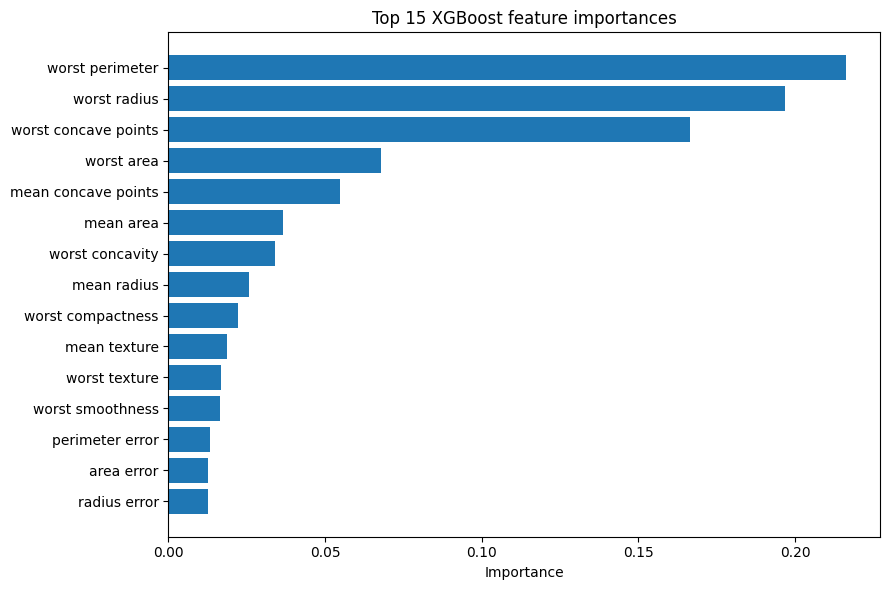

,importance
worst perimeter,0.2163
worst radius,0.1968
worst concave points,0.1666
worst area,0.0679
mean concave points,0.0547
mean area,0.0367
worst concavity,0.0339
mean radius,0.0258
worst compactness,0.0221
mean texture,0.0187


In [17]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns,
    name='importance',
).sort_values(ascending=False)

top_importance = importance.head(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_importance.index, top_importance.values)
plt.xlabel('Importance')
plt.title('Top 15 XGBoost feature importances')
plt.tight_layout()
plt.show()

importance.head(15).to_frame().round(4)

## 16. Common XGBoost parameters — simple reference

These are additional parameters you may encounter. You do not need to tune all of them.

### General and compute parameters

| Parameter | Simple meaning | Typical beginner guidance |
|---|---|---|
| `booster` | Type of base learner: usually trees (`gbtree`), dropout trees (`dart`), or linear (`gblinear`). | Keep `gbtree` for normal tabular problems. |
| `device` | Where training runs, such as `cpu` or `cuda`. | Use `cuda` only when a supported GPU setup is available. |
| `tree_method` | Algorithm used to construct trees. | `hist` is fast and usually a good default. |
| `n_jobs` | Number of CPU threads. | `-1` uses all cores. Limit it when sharing a machine. |
| `verbosity` | Amount of internal logging. | `0` quiet, higher values show more details. |
| `random_state` | Seed for repeatable randomness. | Use a fixed integer during experiments. |
| `missing` | Number used to represent missing values. | Default is `NaN`; XGBoost can learn paths for missing values. |

### Tree size and split parameters

| Parameter | Simple meaning | Higher value usually does what? |
|---|---|---|
| `max_depth` | Deepest allowed tree. | More complex, slower, greater overfitting risk. |
| `min_child_weight` | Minimum evidence required in a child node. | Blocks small or risky splits. |
| `gamma` / `min_split_loss` | Minimum benefit required for a split. | Creates fewer splits. |
| `max_leaves` | Maximum number of leaves. | Allows more complex trees. Mainly useful with histogram methods. |
| `grow_policy` | Order in which the tree grows. | `depthwise` grows level by level; `lossguide` grows the most useful leaf first. |
| `max_bin` | Number of histogram buckets used for continuous values. | Can make split search more precise but uses more memory. |
| `max_delta_step` | Limits how much a leaf score can change. | Makes updates more conservative; sometimes useful for extreme imbalance. |

### Sampling parameters

| Parameter | Simple meaning | Beginner range |
|---|---|---|
| `subsample` | Fraction of training rows used by each tree. | Often `0.6` to `1.0`. |
| `sampling_method` | How sampled rows are chosen. | Usually `uniform`; advanced users may try `gradient_based` with compatible settings. |
| `colsample_bytree` | Fraction of features available to each tree. | Often `0.6` to `1.0`. |
| `colsample_bylevel` | Fraction of available features used at each tree level. | Usually leave at `1.0` initially. |
| `colsample_bynode` | Fraction of available features used at each split node. | Usually leave at `1.0` initially. |

### Regularization parameters

| Parameter | Simple meaning | Higher value usually does what? |
|---|---|---|
| `reg_alpha` | L1 penalty on leaf weights. | Encourages simpler or zero-like leaf effects. |
| `reg_lambda` | L2 penalty on leaf weights. | Smoothly shrinks leaf effects. |

### Learning-task parameters

| Parameter | Simple meaning | Examples |
|---|---|---|
| `objective` | Mathematical job the model performs. | `binary:logistic`, `multi:softprob`, `reg:squarederror`. |
| `eval_metric` | Score monitored during training. | `logloss`, `auc`, `error`, `rmse`, `mae`. |
| `scale_pos_weight` | Extra weight for class 1. | A starting idea is `negative_count / positive_count`, but verify your class definition. |
| `base_score` | Model's starting prediction before trees are added. | Usually leave automatic/default. |

### Training-control parameters

| Parameter | Simple meaning | Guidance |
|---|---|---|
| `n_estimators` | Maximum boosting rounds in the scikit-learn API. | Use a high ceiling with early stopping. |
| `learning_rate` / `eta` | Strength of each new tree. | Smaller values usually need more trees. |
| `early_stopping_rounds` | Stop after this many rounds without validation improvement. | Often `20` to `100`, depending on data and learning rate. |
| `callbacks` | Advanced hooks run during training. | Useful for custom early stopping, logging, or learning-rate schedules. |

### Categorical and constraint parameters

| Parameter | Simple meaning | Guidance |
|---|---|---|
| `enable_categorical` | Allows supported categorical columns to be handled directly. | Ensure columns use pandas `category` dtype and read version-specific documentation. |
| `max_cat_to_onehot` | Decides when small categorical features use one-hot-style splitting. | Advanced; leave default first. |
| `monotone_constraints` | Forces predictions to only increase or decrease with selected features. | Use only with strong domain justification. |
| `interaction_constraints` | Restricts which features may interact in trees. | Advanced governance or domain-control feature. |

> Do not tune every parameter at once. Start with `learning_rate`, `n_estimators`, `max_depth`, `min_child_weight`, `subsample`, and `colsample_bytree`.

## 17. Optional hyperparameter search

A hyperparameter search tests several parameter combinations.

Safe workflow used below:

1. Search using only the **training set** with cross-validation.
2. Compare the chosen model on the separate **validation set**.
3. Keep the **test set untouched** for the final decision.

The cell is disabled by default because search can take longer. Set `RUN_TUNING = True` to run it.

In [18]:
RUN_TUNING = False

if RUN_TUNING:
    search_model = XGBClassifier(
        objective='binary:logistic',
        tree_method='hist',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    parameter_distributions = {
        'n_estimators': [150, 300, 500, 800],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'max_depth': [2, 3, 4, 5, 6],
        'min_child_weight': [1, 2, 4, 8],
        'subsample': [0.7, 0.85, 1.0],
        'colsample_bytree': [0.7, 0.85, 1.0],
        'gamma': [0.0, 0.1, 0.5],
        'reg_alpha': [0.0, 0.01, 0.1, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0, 5.0],
    }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    search = RandomizedSearchCV(
        estimator=search_model,
        param_distributions=parameter_distributions,
        n_iter=20,
        scoring='roc_auc',
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )

    search.fit(X_train, y_train)

    print('Best cross-validation ROC AUC:', search.best_score_)
    print('Best parameters:')
    print(json.dumps(search.best_params_, indent=2))

    tuned_val_metrics, _, _ = evaluate_classifier(
        search.best_estimator_, X_val, y_val, 'tuned_validation'
    )
    display(pd.DataFrame([val_metrics, tuned_val_metrics]).set_index('dataset').round(4))
else:
    print('Tuning skipped. Set RUN_TUNING = True to run the search.')

Tuning skipped. Set RUN_TUNING = True to run the search.


### Parameters inside `RandomizedSearchCV`

| Parameter | Simple meaning |
|---|---|
| `estimator` | The model whose settings are being tested. |
| `param_distributions` | Possible values from which combinations are sampled. |
| `n_iter=20` | Test 20 random combinations rather than every possible combination. |
| `scoring='roc_auc'` | Choose the combination with the best cross-validation ROC AUC. |
| `cv=5-fold` | Divide training data into five rotating train/check portions. |
| `random_state` | Make sampled combinations repeatable. |
| `n_jobs=-1` | Use all CPU cores. |
| `refit=True` | Train one final search winner on all training data. |

Note: the search model does not use the separate validation set during cross-validation. This keeps the validation set available for an independent comparison.

## 18. Save and reload the model

In [19]:
model_path = Path('xgboost_breast_cancer_model.json')
model.save_model(model_path)

loaded_model = XGBClassifier()
loaded_model.load_model(model_path)

same_predictions = np.array_equal(
    model.predict(X_test),
    loaded_model.predict(X_test),
)

print('Saved to:', model_path.resolve())
print('Reloaded model gives identical test classes:', same_predictions)

Saved to: /mnt/data/xgboost_breast_cancer_model.json
Reloaded model gives identical test classes: True


## 19. Practical tuning guide

### When the model underfits

Symptoms:

- Training score is poor.
- Validation score is also poor.

Try:

- Increase `max_depth` slightly.
- Reduce `min_child_weight` or `gamma`.
- Increase `n_estimators`.
- Check whether the features contain useful information.

### When the model overfits

Symptoms:

- Training score is excellent.
- Validation score is much worse.

Try:

- Reduce `max_depth`.
- Increase `min_child_weight` or `gamma`.
- Lower `subsample` or `colsample_bytree` moderately.
- Increase `reg_alpha` or `reg_lambda`.
- Use a lower `learning_rate` with early stopping.

### When training is slow

Try:

- Use `tree_method='hist'`.
- Reduce `n_estimators` during early experiments.
- Reduce `max_depth`.
- Use all appropriate CPU cores with `n_jobs=-1`.
- Consider GPU training only when the data and environment justify it.

## 20. Common mistakes

1. **Tuning on the test set** — produces an optimistic final score.
2. **Preprocessing before the split** — can leak information from test rows.
3. **Using accuracy alone for imbalanced data** — inspect recall, precision, F1, ROC AUC, PR AUC, and the confusion matrix.
4. **Setting very deep trees immediately** — often overfits and consumes memory.
5. **Using too large a learning rate** — can make learning unstable.
6. **Changing many parameters at once** — makes it hard to understand what helped.
7. **Treating feature importance as causation** — importance only describes the fitted model.
8. **Ignoring the positive-class definition** — metrics and `scale_pos_weight` depend on which class is encoded as 1.

## 21. Exercises

1. Change `max_depth` from 4 to 2. Compare training and validation log loss.
2. Change `learning_rate` from 0.03 to 0.1. How does the best iteration change?
3. Set `subsample=1.0` and `colsample_bytree=1.0`. Does validation performance improve?
4. Try `eval_metric='auc'`. Remember that larger AUC is better.
5. Change the classification threshold from 0.5 to 0.3 and compare precision and recall.
6. Run the optional hyperparameter search.
7. Apply the same workflow to your own CSV file.

## 22. Template for your own CSV dataset

Replace the placeholders below. Split before fitting any learned preprocessing step.

In [20]:
# Example template — not executed unless you replace the path and target name.
#
# df = pd.read_csv('your_data.csv')
# TARGET_COLUMN = 'target'
#
# X_custom = df.drop(columns=[TARGET_COLUMN])
# y_custom = df[TARGET_COLUMN]
#
# X_dev, X_test, y_dev, y_test = train_test_split(
#     X_custom,
#     y_custom,
#     test_size=0.15,
#     random_state=42,
#     stratify=y_custom,
# )
#
# X_train, X_val, y_train, y_val = train_test_split(
#     X_dev,
#     y_dev,
#     test_size=0.15 / 0.85,
#     random_state=42,
#     stratify=y_dev,
# )
#
# custom_model = XGBClassifier(
#     objective='binary:logistic',
#     n_estimators=1000,
#     learning_rate=0.03,
#     max_depth=4,
#     tree_method='hist',
#     eval_metric='logloss',
#     early_stopping_rounds=40,
#     random_state=42,
# )
#
# custom_model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_val, y_val)],
#     verbose=False,
# )